# Preamble - Merge Datasets

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
import ast

# 1. Define the column names based on your TSV structure
# The TSV appears to have no header, so we specify them manually
columns_x = ['par_id', 'semeval_id', 'keyword', 'country_code', 'text', 'original_label']

# Load the TSV file (ensure the file path is correct for your machine)
df_x = pd.read_csv('datasets/dontpatronizeme_pcl.tsv', sep='\t', header=None, names=columns_x, skiprows=4)

print(df_x.head())

# Load both the train and dev CSV files
df_train = pd.read_csv('datasets/train_semeval_parids-labels.csv')
df_dev = pd.read_csv('datasets/dev_semeval_parids-labels.csv')

print(df_train.head())
print(df_dev.head())

# Combine both CSV files
df_a = pd.concat([df_train, df_dev], ignore_index=True)

print(f"Combined shape: {df_a.shape}")

# 2. Clean the par_id in df_x (remove '@@') and ensure both are strings for merging
df_x['par_id'] = df_x['par_id'].astype(int)
df_a['par_id'] = df_a['par_id'].astype(int)

# 3. Merge the datasets on 'par_id'
# We use a 'left' merge so we keep all rows from x.tsv even if they aren't in a.csv
df_merged = pd.merge(df_x, df_a, on='par_id', how='right')

# 4. Create the new binary label
def check_for_pcl(label_str):
    if pd.isna(label_str):
        # If there's no match in a.csv, we default to 0 (or you could return the 'original_label')
        return 0
    try:
        # literal_eval safely evaluates the string into a Python list
        categories = ast.literal_eval(label_str)
        # Return 1 if there is at least one '1' in the list, otherwise 0
        return 1 if 1 in categories else 0
    except:
        # Fallback for any parsing errors
        return 0

# Apply the function to create our new target column
df_merged['final_label'] = df_merged['label'].apply(check_for_pcl)

# (Optional) Drop the old confusing label columns to keep the dataset clean
df_merged = df_merged.drop(columns=['original_label', 'label'])

# 5. Save the transformed data
output_file = 'merged_pcl_dataset.csv'
df_merged.to_csv(output_file, index=False)

print(f"Data successfully joined and transformed! Saved to {output_file}.")
# Preview the first few rows
print(df_merged[['par_id', 'keyword', 'final_label']].head(10))

   par_id  semeval_id    keyword country_code  \
0       1  @@24942188   hopeless           ph   
1       2  @@21968160    migrant           gh   
2       3  @@16584954  immigrant           ie   
3       4   @@7811231   disabled           nz   
4       5   @@1494111    refugee           ca   

                                                text  original_label  
0  We 're living in times of absolute insanity , ...               0  
1  In Libya today , there are countless number of...               0  
2  White House press secretary Sean Spicer said t...               0  
3  Council customers only signs would be displaye...               0  
4  " Just like we received migrants fleeing El Sa...               0  
   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]
   par_id                  label
0    4046  [1, 0, 0, 1, 0, 0, 0]
1    1279  [0, 

# Exercise 2
  

### Basical Statistical Profiling

{'mean_length': np.float64(43.193619256853566), 'median_length': 37.0, 'min_length': 0, 'max_length': 819, 'p95_length': np.float64(91.0)}


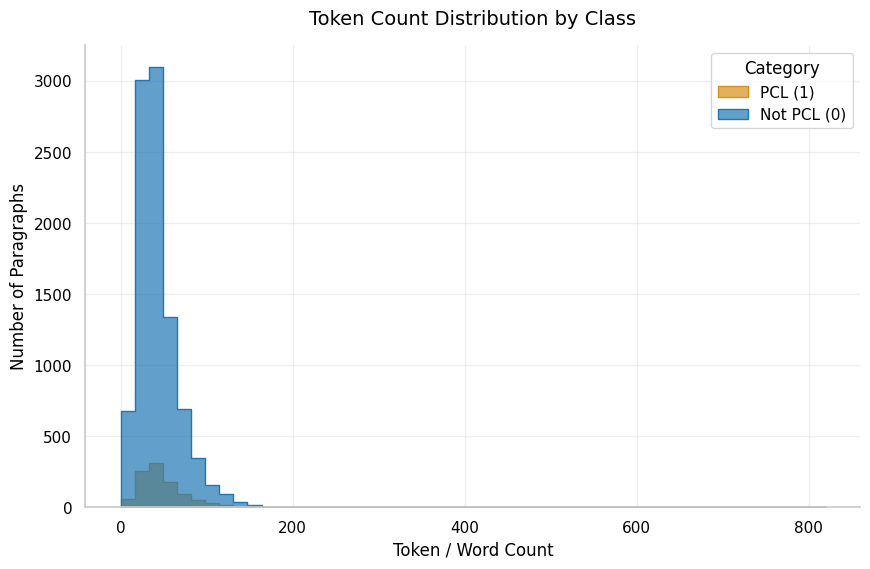

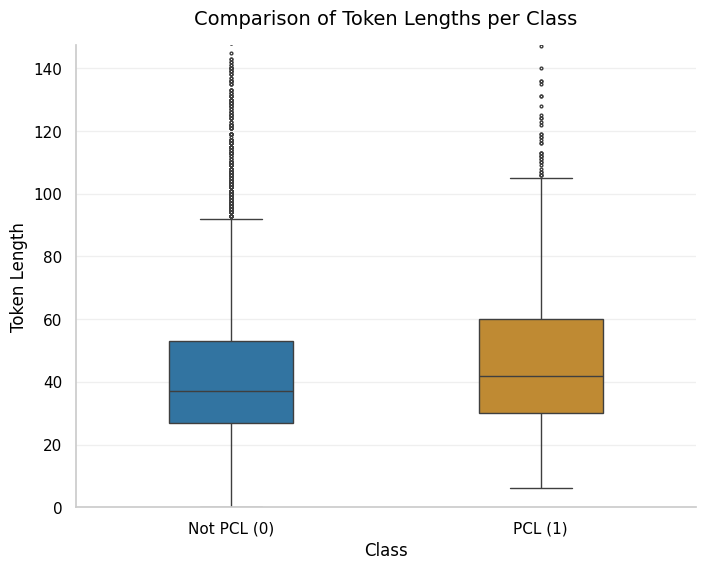

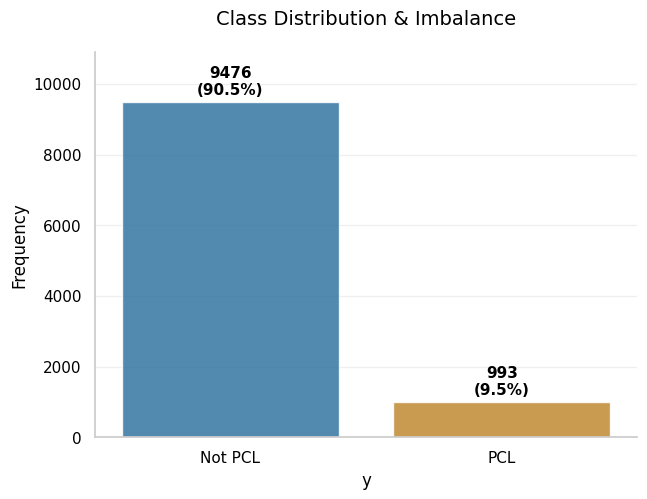


Vocabulary Size: 29091
Total Tokens: 452194

Top 20 Words: [('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239)]


In [14]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['text.color'] = '#000000'
plt.rcParams['axes.labelcolor'] = '#000000'
plt.rcParams['xtick.color'] = '#000000'
plt.rcParams['ytick.color'] = '#000000'

path = "EDA/Statistical_Profiling_Diagrams"
folder_path = Path(path)
folder_path.mkdir(parents=True, exist_ok=True)

# --- DATA PREPARATION ---
# Loading your dataset
df = pd.read_csv('datasets/merged_pcl_dataset.csv')

df['y'] = df['final_label'].astype(int)

# Tokenization logic
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['length'] = df['tokens'].apply(len)

token_stats = {
    "mean_length": df["length"].mean(),
    "median_length": df["length"].median(),
    "min_length": df["length"].min(),
    "max_length": df["length"].max(),
    "p95_length": df["length"].quantile(0.95)
}

print(token_stats)

# --- VISUALIZATION 1: TOKEN COUNT DISTRIBUTION ---

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="length", hue="y", bins=50, kde=False,
             palette={0: "#1f77b4", 1: "#d6901c"}, alpha=0.7, element="step")

# p95 = token_stats["p95_length"]
# plt.axvline(p95, color='#C44E52', linestyle='--', linewidth=2,
#             label=f'95th Percentile ({p95:.0f} tokens)')

plt.xlabel("Token / Word Count")
plt.ylabel("Number of Paragraphs")
plt.title("Token Count Distribution by Class", fontsize=14, pad=15)
plt.legend(title="Category", labels=["PCL (1)", "Not PCL (0)", "95th Percentile"])

plt.savefig(f"{path}/length_distribution_styled.png", bbox_inches='tight')
plt.show()

# --- VISUALIZATION 2: LENGTH BY CLASS (BOXPLOT) ---

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x="y", y="length", hue="y",
            palette={0: "#1f77b4", 1: "#d6901c"},
            width=0.4, fliersize=2, legend=False)

plt.title("Comparison of Token Lengths per Class", fontsize=14, pad=15)
plt.xticks([0, 1], ["Not PCL (0)", "PCL (1)"])
plt.xlabel("Class")
plt.ylabel("Token Length")
plt.ylim(0, df["length"].quantile(0.99) + 20)

plt.savefig(f"{path}/length_boxplot_styled.png", bbox_inches='tight')
plt.show()

# --- VISUALIZATION 3: CLASS DISTRIBUTION BAR ---
plt.figure(figsize=(7, 5))
class_counts = df["y"].value_counts().sort_index()
total = len(df)

# FIX: Added hue to match newer Seaborn requirements
ax = sns.barplot(x=class_counts.index, y=class_counts.values,
                 hue=class_counts.index, palette={0: "#1f77b4", 1: "#d6901c"},
                 alpha=0.85, legend=False)

for i, p in enumerate(ax.patches):
    count = class_counts.values[i]
    percentage = (count / total) * 100
    ax.annotate(f'{int(count)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11,
                xytext=(0, 15), textcoords='offset points', fontweight='bold')

plt.title("Class Distribution & Imbalance", fontsize=14, pad=20)
plt.xticks([0, 1], ["Not PCL", "PCL"])
plt.ylabel("Frequency")
plt.ylim(0, max(class_counts.values) * 1.15)

plt.savefig(f"{path}/class_distribution_styled.png", bbox_inches='tight')
plt.show()

# Textual Summary
all_tokens = [token for tokens in df['tokens'] for token in tokens]
print(f"\nVocabulary Size: {len(set(all_tokens))}")
print(f"Total Tokens: {len(all_tokens)}")
print("\nTop 20 Words:", Counter(all_tokens).most_common(20))

### Lexical Analysis


===== DUPLICATE DETECTION =====

Exact Text Duplicates: 0 rows
  Unique duplicate texts: 0

Checking for duplicates with conflicting labels:

===== SPECIAL CHARACTERS & HTML DETECTION =====

HTML/Special Character Patterns Found:
  amp: 61 rows (0.58%)
  lt: 0 rows (0.00%)
  gt: 17 rows (0.16%)
  quot: 0 rows (0.00%)
  apos: 0 rows (0.00%)
  html_tags: 401 rows (3.83%)
  newlines: 0 rows (0.00%)
  tabs: 0 rows (0.00%)
  unicode_escapes: 0 rows (0.00%)

Punctuation Statistics:
  Mean punctuation density: 0.0239
  Max punctuation density: 0.2000
  Rows with >50% punctuation: 0

Non-ASCII Characters:
  Rows with non-ASCII: 0 (0.00%)

===== OUTLIER DETECTION =====

Token Count Statistics:
  Mean: 43.19
  Median: 37.00
  Std Dev: 26.01
  Min: 0
  Max: 819
  Q1 (25%): 27.00
  Q3 (75%): 53.00

Outliers (IQR method):
  Lower bound: -12.00 tokens
  Upper bound: 92.00 tokens
  Total outliers: 490 rows (4.68%)

Very Short Texts (<5 tokens): 23 rows (0.22%)
  Examples:
    'The Filipino immigrant

/tmp/ipykernel_1425/1649815055.py:200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])


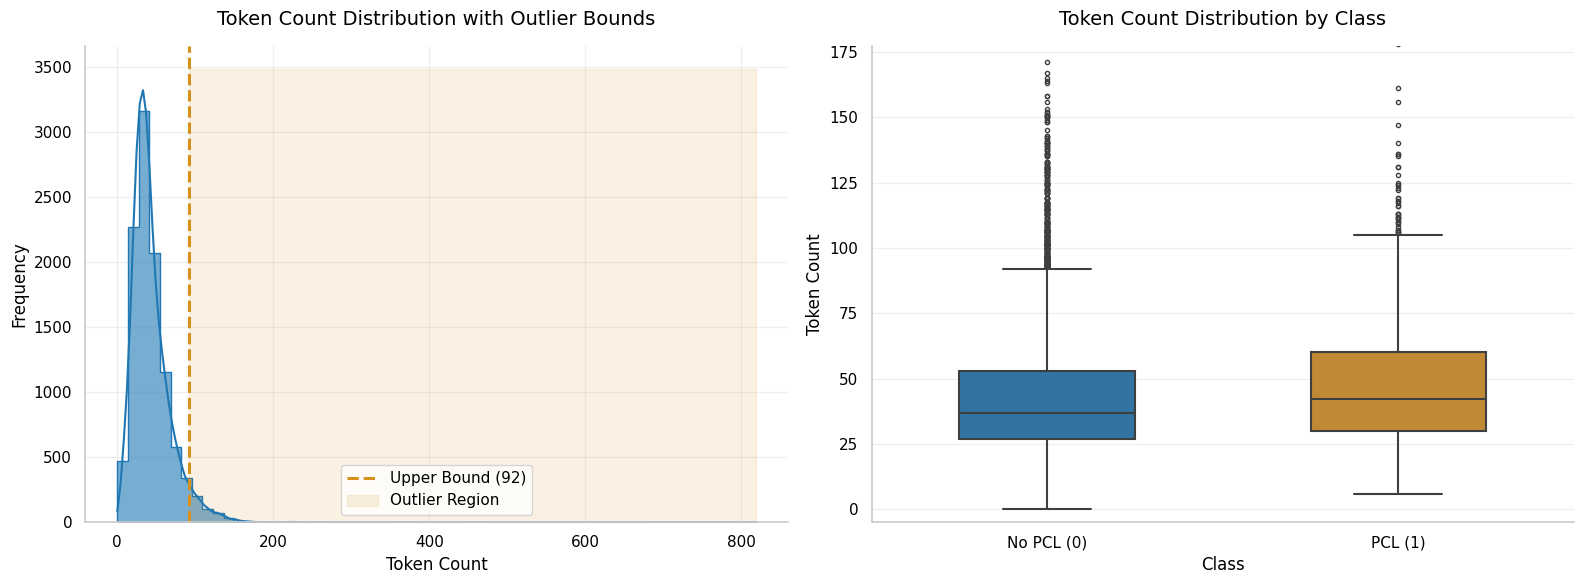


===== NOISE SUMMARY REPORT =====

Total Records: 10469

1. DUPLICATES:
   - Exact duplicates: 0

2. SPECIAL CHARACTERS/HTML:
   - Non-ASCII rows: 0
   - High punctuation (>50%): 0

3. OUTLIERS:
   - Length outliers: 490
   - Very short (<5 tokens): 23
   - Very long (>200 tokens): 9

Outliers saved to: EDA/LexicalAnalysis/outliers_detected.csv

===== N-GRAM ANALYSIS =====

Bigrams: 441726 total
Trigrams: 431259 total

Top 20 Bigrams:
  1. 'of the': 2711
  2. 'in the': 2460
  3. 'to the': 1315
  4. 'in need': 1025
  5. 'poor families': 921
  6. 'for the': 873
  7. 'on the': 811
  8. 'to be': 740
  9. 'and the': 734
  10. 'at the': 653
  11. 'need of': 605
  12. 'in a': 587
  13. 'by the': 563
  14. 'that the': 549
  15. 'of a': 541
  16. 'from the': 535
  17. 'with the': 502
  18. 'it is': 497
  19. 'is a': 448
  20. 'as a': 443

Top 20 Trigrams:
  1. 'in need of': 594
  2. 'from poor families': 230
  3. 'one of the': 190
  4. 'those in need': 162
  5. 'as well as': 153
  6. 'the unite

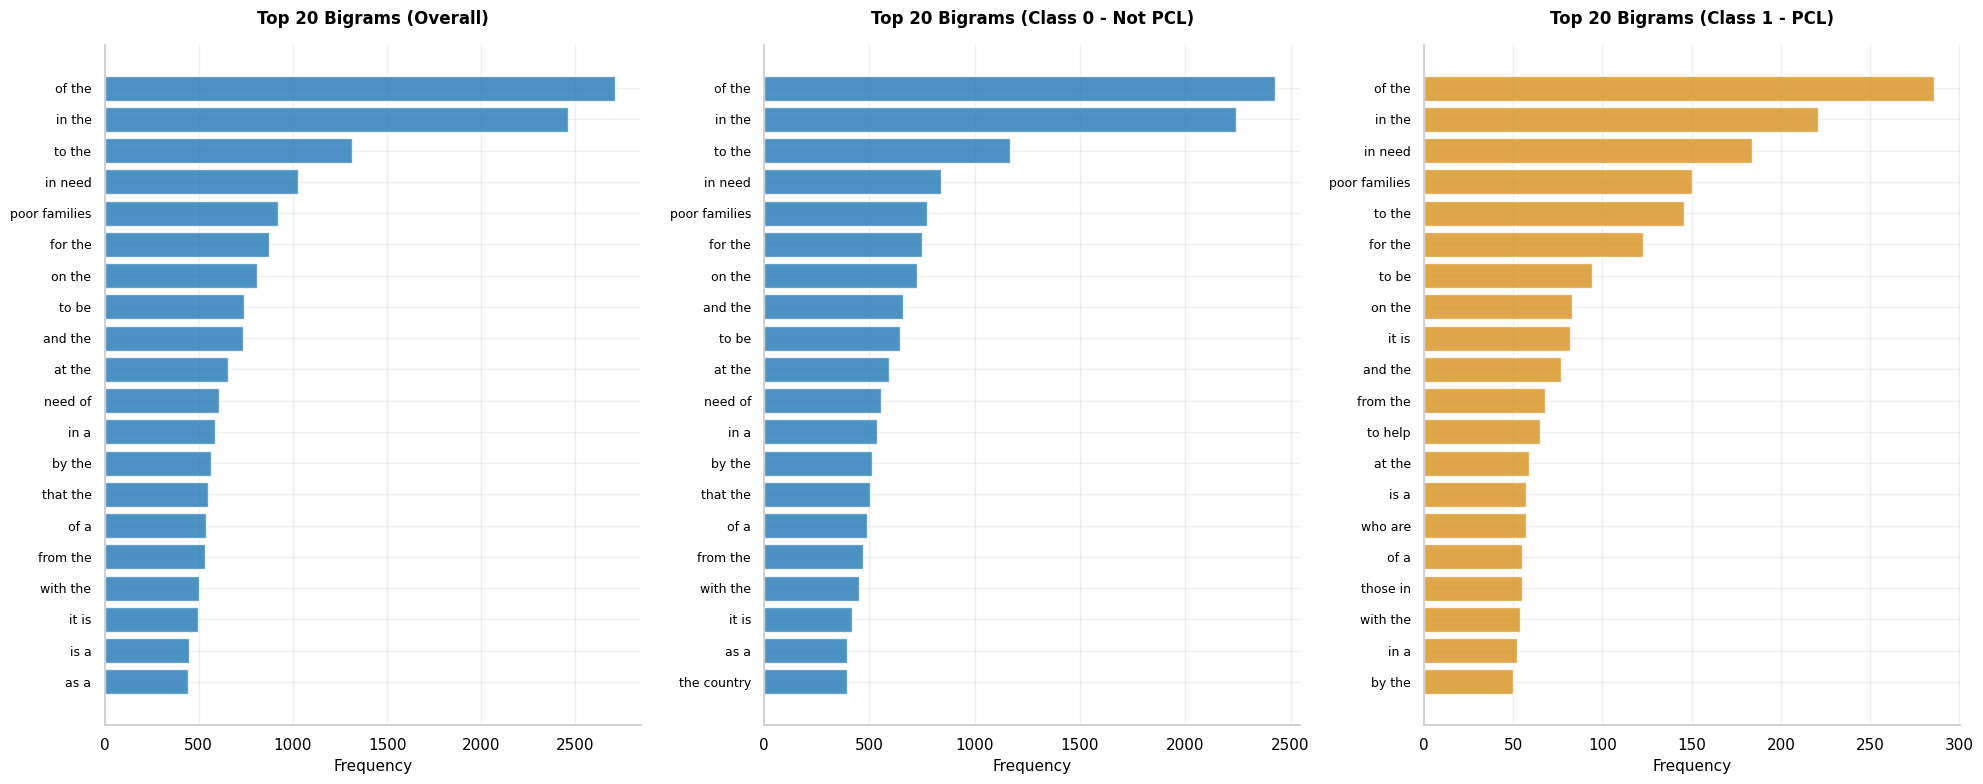

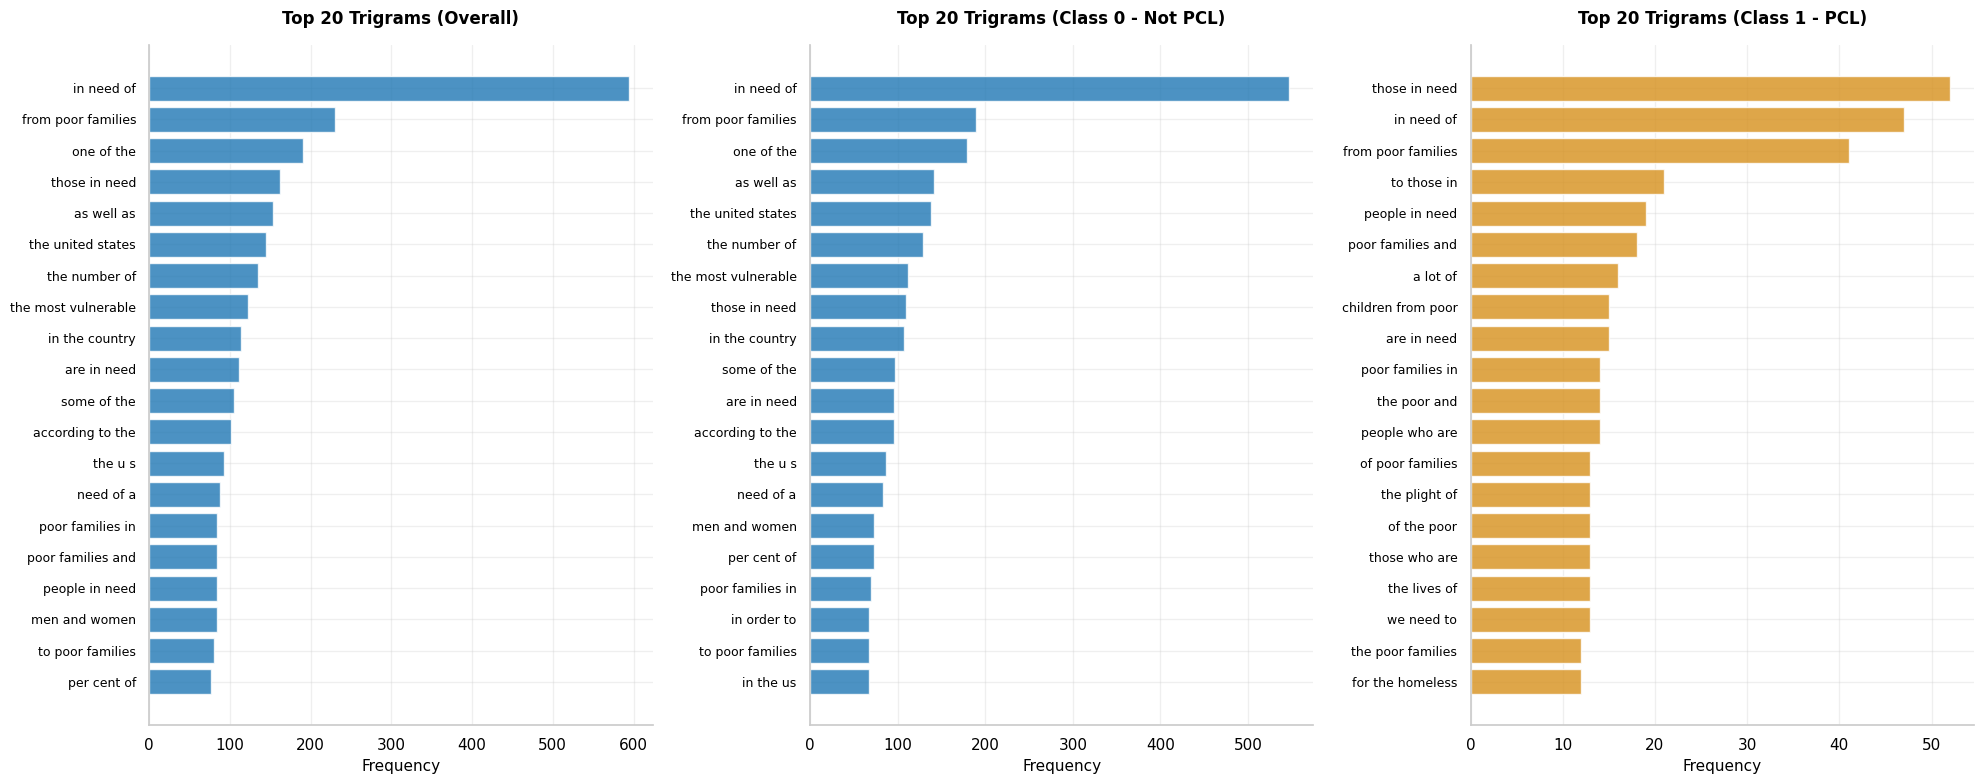


N-gram visualizations saved to: EDA/LexicalAnalysis/


In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['text.color'] = '#000000'
plt.rcParams['axes.labelcolor'] = '#000000'
plt.rcParams['xtick.color'] = '#000000'
plt.rcParams['ytick.color'] = '#000000'

# Define the folder name/path
folder_path = Path("EDA/LexicalAnalysis")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('datasets/merged_pcl_dataset.csv')
df['y'] = (df['final_label'] == 1).astype(int)

# DUPLICATES

print("\n===== DUPLICATE DETECTION =====")

# Check for exact text duplicates
exact_duplicates = df[df.duplicated(subset=['text'], keep=False)]
num_exact_duplicates = len(exact_duplicates)
print(f"\nExact Text Duplicates: {num_exact_duplicates} rows")
print(f"  Unique duplicate texts: {df['text'].duplicated().sum()}")

if num_exact_duplicates > 0:
    print("\nSample duplicate texts:")
    dup_texts = df['text'].value_counts()
    dup_texts = dup_texts[dup_texts > 1]
    for text, count in dup_texts.head(5).items():
        print(f"  '{text[:80]}...' appears {count} times")

# Check for near-duplicates (same text with different labels)
print("\nChecking for duplicates with conflicting labels:")
for text, group in df.groupby('text'):
    if len(group['y'].unique()) > 1:
        print(f"  Conflicting labels for: '{text[:80]}...'")
        print(f"    Labels: {group['y'].unique()}")
        break

# SPECIAL CHARACTERS & HTML

print("\n===== SPECIAL CHARACTERS & HTML DETECTION =====")

# Common HTML entities and special patterns
html_patterns = {
    'amp': r'&amp;',
    'lt': r'&lt;',
    'gt': r'&gt;',
    'quot': r'&quot;',
    'apos': r'&apos;',
    'html_tags': r'<[^>]+>',
    'newlines': r'\\n|\n',
    'tabs': r'\\t|\t',
    'unicode_escapes': r'\\u[0-9a-fA-F]{4}',
}

print("\nHTML/Special Character Patterns Found:")
for pattern_name, pattern in html_patterns.items():
    count = df['text'].str.contains(pattern, regex=True, na=False).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pattern_name}: {count} rows ({percentage:.2f}%)")

    if count > 0 and count <= 5:
        print(f"    Examples:")
        examples = df[df['text'].str.contains(pattern, regex=True, na=False)]['text'].head(3)
        for ex in examples:
            print(f"      '{ex[:80]}...'")

# Check for excessive punctuation
def count_punctuation(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[!?.,;:\-\(\)\[\]{}\"\'\/\\@#$%^&*+=]', text))

df['punctuation_count'] = df['text'].apply(count_punctuation)
df['punctuation_density'] = df['punctuation_count'] / df['text'].str.len()

print(f"\nPunctuation Statistics:")
print(f"  Mean punctuation density: {df['punctuation_density'].mean():.4f}")
print(f"  Max punctuation density: {df['punctuation_density'].max():.4f}")
print(f"  Rows with >50% punctuation: {(df['punctuation_density'] > 0.5).sum()}")

# Check for non-ASCII characters
def has_non_ascii(text):
    if not isinstance(text, str):
        return False
    return any(ord(char) > 127 for char in text)

non_ascii_count = df['text'].apply(has_non_ascii).sum()
print(f"\nNon-ASCII Characters:")
print(f"  Rows with non-ASCII: {non_ascii_count} ({(non_ascii_count/len(df)*100):.2f}%)")

######## OUTLIERS #######

print("\n===== OUTLIER DETECTION =====")

# Text length analysis
df['text_length'] = df['text'].str.len()

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['token_count'] = df['tokens'].apply(len)

print(f"\nToken Count Statistics:")
print(f"  Mean: {df['token_count'].mean():.2f}")
print(f"  Median: {df['token_count'].median():.2f}")
print(f"  Std Dev: {df['token_count'].std():.2f}")
print(f"  Min: {df['token_count'].min()}")
print(f"  Max: {df['token_count'].max()}")
print(f"  Q1 (25%): {df['token_count'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df['token_count'].quantile(0.75):.2f}")

# IQR-based outlier detection
Q1 = df['token_count'].quantile(0.25)
Q3 = df['token_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['token_count'] < lower_bound) | (df['token_count'] > upper_bound)]
print(f"\nOutliers (IQR method):")
print(f"  Lower bound: {lower_bound:.2f} tokens")
print(f"  Upper bound: {upper_bound:.2f} tokens")
print(f"  Total outliers: {len(outliers)} rows ({(len(outliers)/len(df)*100):.2f}%)")

# Short texts (< 5 tokens)
short_texts = df[df['token_count'] < 5]
print(f"\nVery Short Texts (<5 tokens): {len(short_texts)} rows ({(len(short_texts)/len(df)*100):.2f}%)")
if len(short_texts) > 0:
    print(f"  Examples:")
    for text in short_texts['text'].head(5):
        print(f"    '{text}'")

# Long texts (> 200 tokens)
long_texts = df[df['token_count'] > 200]
print(f"\nVery Long Texts (>200 tokens): {len(long_texts)} rows ({(len(long_texts)/len(df)*100):.2f}%)")
if len(long_texts) > 0:
    print(f"  Sample long text length: {long_texts['token_count'].iloc[0]} tokens")

# Class-wise outlier analysis
print(f"\nOutlier Distribution by Class:")
print(f"  Class 0 (No PCL) outliers: {len(outliers[outliers['y']==0])} / {(outliers['y']==0).sum()}")
print(f"  Class 1 (PCL) outliers: {len(outliers[outliers['y']==1])} / {(outliers['y']==1).sum()}")

# --- IMPROVED VISUALIZATIONS ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram with Outlier bounds highlighted

sns.histplot(data=df, x='token_count', bins=60, kde=True, ax=axes[0],
             color="#1f77b4", alpha=0.6, element="step")

# Highlight lower bound (if applicable/above 0) and upper bound
if lower_bound > 0:
    axes[0].axvline(lower_bound, color='#d6901c', linestyle='--', linewidth=2.2, label=f'Lower Bound ({lower_bound:.0f})')
axes[0].axvline(upper_bound, color='#d6901c', linestyle='--', linewidth=2.2, label=f'Upper Bound ({upper_bound:.0f})')

# Shade the upper outlier region
y_min, y_max = axes[0].get_ylim()
axes[0].fill_betweenx([y_min, y_max], upper_bound, df['token_count'].max(),
                      color='#d6901c', alpha=0.12, label='Outlier Region')

axes[0].set_xlabel('Token Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Token Count Distribution with Outlier Bounds', fontsize=14, pad=15)
axes[0].legend()

# 2. Box plot by class

sns.boxplot(data=df, x='y', y='token_count', hue='y', ax=axes[1],
            palette={0: "#1f77b4", 1: "#d6901c"},
            width=0.5, fliersize=3, linewidth=1.5, legend=False)

axes[1].set_ylabel('Token Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])
axes[1].set_title('Token Count Distribution by Class', fontsize=14, pad=15)

# Optional: Focus the y-axis to see the IQR boxes clearly if extreme outliers squash them
axes[1].set_ylim(-5, df['token_count'].quantile(0.99) + 50)

plt.tight_layout()
plt.savefig(f'{folder_path}/outlier_detection_styled.png', bbox_inches='tight')
plt.show()

######## SUMMARY REPORT #######

print("\n===== NOISE SUMMARY REPORT =====")
print(f"\nTotal Records: {len(df)}")
print(f"\n1. DUPLICATES:")
print(f"   - Exact duplicates: {df['text'].duplicated().sum()}")
print(f"\n2. SPECIAL CHARACTERS/HTML:")
print(f"   - Non-ASCII rows: {non_ascii_count}")
print(f"   - High punctuation (>50%): {(df['punctuation_density'] > 0.5).sum()}")
print(f"\n3. OUTLIERS:")
print(f"   - Length outliers: {len(outliers)}")
print(f"   - Very short (<5 tokens): {len(short_texts)}")
print(f"   - Very long (>200 tokens): {len(long_texts)}")

# Save outlier info to CSV for further inspection
if len(outliers) > 0:
    outliers_to_inspect = outliers[['text', 'token_count', 'final_label', 'y']].copy()
    outliers_to_inspect.to_csv(f'{folder_path}/outliers_detected.csv', index=False)
    print(f"\nOutliers saved to: {folder_path}/outliers_detected.csv")

######## N-GRAM ANALYSIS #######

print("\n===== N-GRAM ANALYSIS =====")

# Function to extract n-grams from token lists
def extract_ngrams(token_lists, n):
    """Extract n-grams from a list of token lists"""
    ngrams = []
    for tokens in token_lists:
        if len(tokens) >= n:
            for i in range(len(tokens) - n + 1):
                ngram = ' '.join(tokens[i:i+n])
                ngrams.append(ngram)
    return ngrams

# Extract bigrams and trigrams
all_bigrams = extract_ngrams(df['tokens'], 2)
all_trigrams = extract_ngrams(df['tokens'], 3)

print(f"\nBigrams: {len(all_bigrams)} total")
print(f"Trigrams: {len(all_trigrams)} total")

# Count n-grams
bigram_counter = Counter(all_bigrams)
trigram_counter = Counter(all_trigrams)

top_20_bigrams = bigram_counter.most_common(20)
top_20_trigrams = trigram_counter.most_common(20)

print(f"\nTop 20 Bigrams:")
for i, (bigram, count) in enumerate(top_20_bigrams, 1):
    print(f"  {i}. '{bigram}': {count}")

print(f"\nTop 20 Trigrams:")
for i, (trigram, count) in enumerate(top_20_trigrams, 1):
    print(f"  {i}. '{trigram}': {count}")

# Extract n-grams by class
class_0_bigrams = extract_ngrams(df[df['y'] == 0]['tokens'], 2)
class_1_bigrams = extract_ngrams(df[df['y'] == 1]['tokens'], 2)

class_0_trigrams = extract_ngrams(df[df['y'] == 0]['tokens'], 3)
class_1_trigrams = extract_ngrams(df[df['y'] == 1]['tokens'], 3)

class_0_bigram_counter = Counter(class_0_bigrams)
class_1_bigram_counter = Counter(class_1_bigrams)

class_0_trigram_counter = Counter(class_0_trigrams)
class_1_trigram_counter = Counter(class_1_trigrams)

top_20_class_0_bigrams = class_0_bigram_counter.most_common(20)
top_20_class_1_bigrams = class_1_bigram_counter.most_common(20)

top_20_class_0_trigrams = class_0_trigram_counter.most_common(20)
top_20_class_1_trigrams = class_1_trigram_counter.most_common(20)

# --- BIGRAM VISUALIZATIONS (Overall + By Class) ---

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Overall Bigrams
bigrams, counts = zip(*top_20_bigrams)
y_pos = np.arange(len(bigrams))
axes[0].barh(y_pos, counts, color="#1f77b4", alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(bigrams, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_title('Top 20 Bigrams (Overall)', fontsize=12, pad=15, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Class 0 Bigrams
bigrams_0, counts_0 = zip(*top_20_class_0_bigrams) if top_20_class_0_bigrams else ([], [])
y_pos = np.arange(len(bigrams_0))
axes[1].barh(y_pos, counts_0, color="#1f77b4", alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(bigrams_0, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_title('Top 20 Bigrams (Class 0 - Not PCL)', fontsize=12, pad=15, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Class 1 Bigrams
bigrams_1, counts_1 = zip(*top_20_class_1_bigrams) if top_20_class_1_bigrams else ([], [])
y_pos = np.arange(len(bigrams_1))
axes[2].barh(y_pos, counts_1, color="#d6901c", alpha=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(bigrams_1, fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel('Frequency', fontsize=11)
axes[2].set_title('Top 20 Bigrams (Class 1 - PCL)', fontsize=12, pad=15, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{folder_path}/top_20_bigrams_all.png', bbox_inches='tight', dpi=300)
plt.show()

# --- TRIGRAM VISUALIZATIONS (Overall + By Class) ---

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Overall Trigrams
trigrams, counts = zip(*top_20_trigrams)
y_pos = np.arange(len(trigrams))
axes[0].barh(y_pos, counts, color="#1f77b4", alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(trigrams, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_title('Top 20 Trigrams (Overall)', fontsize=12, pad=15, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Class 0 Trigrams
trigrams_0, counts_0 = zip(*top_20_class_0_trigrams) if top_20_class_0_trigrams else ([], [])
y_pos = np.arange(len(trigrams_0))
axes[1].barh(y_pos, counts_0, color="#1f77b4", alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(trigrams_0, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_title('Top 20 Trigrams (Class 0 - Not PCL)', fontsize=12, pad=15, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Class 1 Trigrams
trigrams_1, counts_1 = zip(*top_20_class_1_trigrams) if top_20_class_1_trigrams else ([], [])
y_pos = np.arange(len(trigrams_1))
axes[2].barh(y_pos, counts_1, color="#d6901c", alpha=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(trigrams_1, fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel('Frequency', fontsize=11)
axes[2].set_title('Top 20 Trigrams (Class 1 - PCL)', fontsize=12, pad=15, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{folder_path}/top_20_trigrams_all.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nN-gram visualizations saved to: {folder_path}/")

### Identifying Noise


===== N-GRAM ANALYSIS =====

Top 20 Bigrams:
[(('of', 'the'), 2711), (('in', 'the'), 2460), (('to', 'the'), 1315), (('in', 'need'), 1025), (('poor', 'families'), 921), (('for', 'the'), 873), (('on', 'the'), 811), (('to', 'be'), 740), (('and', 'the'), 734), (('at', 'the'), 653), (('need', 'of'), 605), (('in', 'a'), 587), (('by', 'the'), 563), (('that', 'the'), 549), (('of', 'a'), 541), (('from', 'the'), 535), (('with', 'the'), 502), (('it', 'is'), 497), (('is', 'a'), 448), (('as', 'a'), 443)]

Top 20 Trigrams:
[(('in', 'need', 'of'), 594), (('from', 'poor', 'families'), 230), (('one', 'of', 'the'), 190), (('those', 'in', 'need'), 162), (('as', 'well', 'as'), 153), (('the', 'united', 'states'), 145), (('the', 'number', 'of'), 135), (('the', 'most', 'vulnerable'), 122), (('in', 'the', 'country'), 114), (('are', 'in', 'need'), 111), (('some', 'of', 'the'), 105), (('according', 'to', 'the'), 101), (('the', 'u', 's'), 93), (('need', 'of', 'a'), 88), (('poor', 'families', 'in'), 84), (('poor

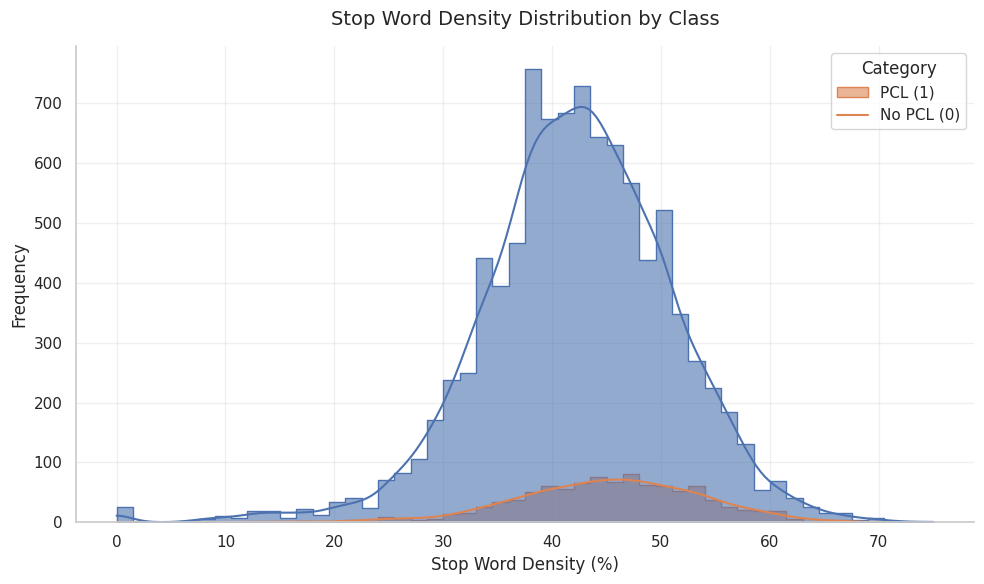


===== WORD CLOUDS & FREQUENCY =====


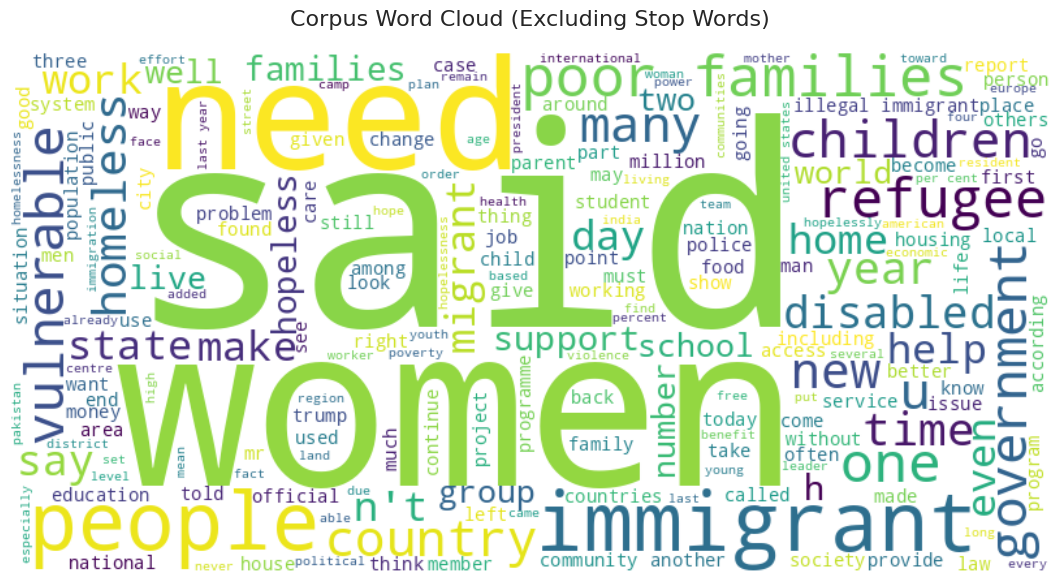

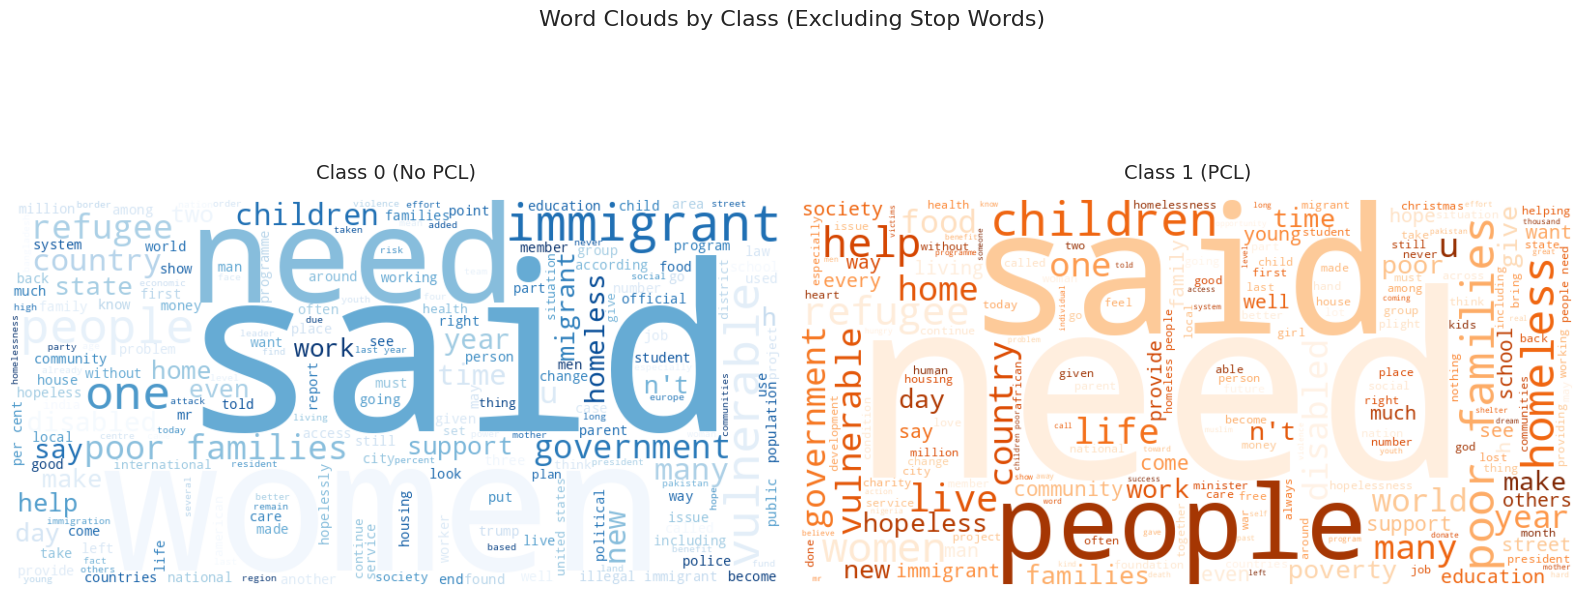

/tmp/ipykernel_1425/1813051379.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)


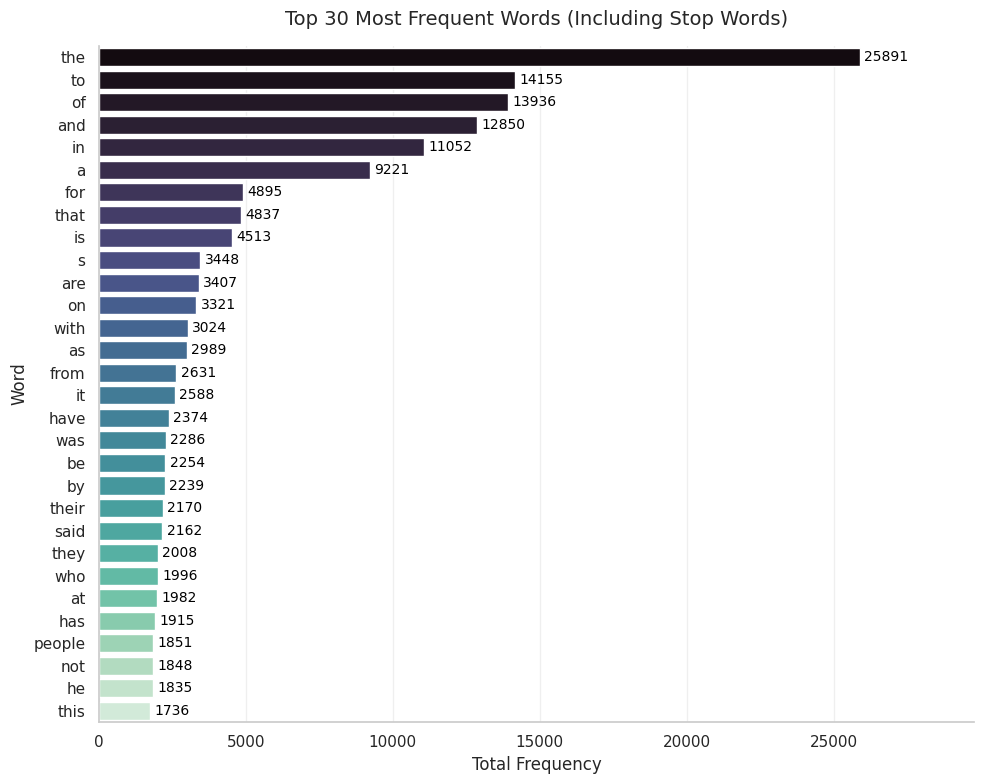


Top 30 Words (including stop words):
[('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239), ('their', 2170), ('said', 2162), ('they', 2008), ('who', 1996), ('at', 1982), ('has', 1915), ('people', 1851), ('not', 1848), ('he', 1835), ('this', 1736)]

Top 30 Words (excluding stop words):
[('said', 2162), ('people', 1851), ('women', 1718), ('need', 1344), ('families', 1341), ('immigrants', 1296), ('vulnerable', 1204), ('poor', 1190), ('disabled', 1145), ('children', 1039), ('homeless', 1035), ('also', 985), ('refugees', 966), ('one', 953), ('government', 852), ('would', 818), ('new', 808), ('many', 789), ('country', 751), ('year', 747), ("n't", 687), ('us', 628), ('immigrant', 550), ('help', 540), ('h', 538), ('hopeless', 535), ('two', 524), ('time', 

In [16]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from pathlib import Path

# Download required NLTK resources
nltk.download('stopwords', quiet=True)

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3

# Define the folder name/path
folder_path = Path("EDA/NoiseArtifacts")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('datasets/merged_pcl_dataset.csv')
# Ensure labels are integers for categorical plotting
df['y'] = (df['final_label'] >= 1).astype(int)

# Create a column for tokenized text
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)

# Get English stop words
stop_words = set(stopwords.words('english'))

######## N-GRAM ANALYSIS #######

def get_ngrams(tokens, n):
    """Extract n-grams from token list"""
    return list(ngrams(tokens, n))

# Get all bigrams and trigrams
all_tokens = [token for tokens in df['tokens'] for token in tokens]
all_bigrams = [bigram for tokens in df['tokens'] for bigram in get_ngrams(tokens, 2)]
all_trigrams = [trigram for tokens in df['tokens'] for trigram in get_ngrams(tokens, 3)]

bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

print("\n===== N-GRAM ANALYSIS =====")
print("\nTop 20 Bigrams:")
print(bigram_counts.most_common(20))

print("\nTop 20 Trigrams:")
print(trigram_counts.most_common(20))

# By class
print("\n--- Bigrams by Class ---")
class_0_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 0
                    for bigram in get_ngrams(tokens, 2)]
class_1_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 1
                    for bigram in get_ngrams(tokens, 2)]

class_0_bigram_counts = Counter(class_0_bigrams)
class_1_bigram_counts = Counter(class_1_bigrams)

print("\nTop 15 Bigrams (Class 0 - No PCL):")
print(class_0_bigram_counts.most_common(15))

print("\nTop 15 Bigrams (Class 1 - PCL):")
print(class_1_bigram_counts.most_common(15))

######## STOP WORD DENSITY #######

print("\n===== STOP WORD DENSITY =====")

def calculate_stop_word_density(tokens):
    """Calculate percentage of stop words in token list"""
    if len(tokens) == 0:
        return 0
    stop_word_count = sum(1 for token in tokens if token in stop_words)
    return (stop_word_count / len(tokens)) * 100

df['stop_word_density'] = df['tokens'].apply(calculate_stop_word_density)

print(f"\nOverall Stop Word Density:")
print(f"  Mean: {df['stop_word_density'].mean():.2f}%")
print(f"  Median: {df['stop_word_density'].median():.2f}%")
print(f"  Min: {df['stop_word_density'].min():.2f}%")
print(f"  Max: {df['stop_word_density'].max():.2f}%")

print(f"\nStop Word Density by Class:")
print(f"  Class 0 (No PCL) - Mean: {df[df['y']==0]['stop_word_density'].mean():.2f}%")
print(f"  Class 1 (PCL) - Mean: {df[df['y']==1]['stop_word_density'].mean():.2f}%")

# Visualize stop word density distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='stop_word_density', hue='y', bins=50, kde=True,
             palette={0: "#4C72B0", 1: "#DD8452"}, alpha=0.6, element="step")

plt.xlabel('Stop Word Density (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Stop Word Density Distribution by Class', fontsize=14, pad=15)
plt.legend(title="Category", labels=["PCL (1)", "No PCL (0)"])

plt.tight_layout()
plt.savefig(f'{folder_path}/stop_word_density_styled.png')
plt.show()

######## WORD CLOUDS & FREQUENCY #######

print("\n===== WORD CLOUDS & FREQUENCY =====")

# Overall word cloud

all_text = ' '.join([token for tokens in df['tokens'] for token in tokens if token not in stop_words])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Corpus Word Cloud (Excluding Stop Words)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_all_styled.png')
plt.show()

# Word cloud by class
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Class 0
class_0_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 0
                          for token in tokens if token not in stop_words])
wordcloud_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(class_0_text)
axes[0].imshow(wordcloud_0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Class 0 (No PCL)', fontsize=14, pad=15)

# Class 1
class_1_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 1
                          for token in tokens if token not in stop_words])
wordcloud_1 = WordCloud(width=800, height=400, background_color='white', colormap='Oranges').generate(class_1_text)
axes[1].imshow(wordcloud_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Class 1 (PCL)', fontsize=14, pad=15)

plt.suptitle('Word Clouds by Class (Excluding Stop Words)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_by_class_styled.png', bbox_inches='tight')
plt.show()

# Word frequency (top 30)

fig, ax = plt.subplots(figsize=(10, 8))
top_30_tokens = Counter(all_tokens).most_common(30)
tokens_only, freqs = zip(*top_30_tokens)

# Modern Seaborn Horizontal Barplot
sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)

ax.set_xlabel('Total Frequency', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title('Top 30 Most Frequent Words (Including Stop Words)', fontsize=14, pad=15)

# Add numeric labels to the end of each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 150, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, color='black')

# Expand x-axis slightly to make room for the text annotations
ax.set_xlim(0, max(freqs) * 1.15)

plt.tight_layout()
plt.savefig(f'{folder_path}/top_30_words_styled.png')
plt.show()

print("\nTop 30 Words (including stop words):")
print(Counter(all_tokens).most_common(30))

print("\nTop 30 Words (excluding stop words):")
non_stop_tokens = [token for token in all_tokens if token not in stop_words]
print(Counter(non_stop_tokens).most_common(30))

# Exercise 4 - Train the Model

In [41]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import random
from sklearn.model_selection import train_test_split


# ==============================================================
# 0. Reproducibility: Fix All Random Seeds
# ==============================================================

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print(f"Seed initialised to {RANDOM_STATE}")


# ==============================================================
# 1. Project Folder Configuration
# ==============================================================

# Define base working directory (created if absent)
project_root = Path("/content/pcl_roberta_project_2")
project_root.mkdir(parents=True, exist_ok=True)

hf_cache_dir = project_root / "hf_cache"
checkpoint_dir = project_root / "checkpoints"
tensorboard_dir = project_root / "logs"
final_model_dir = project_root / "best_pcl_model"

print(f"Working directory: {project_root}")


# ==============================================================
# 2. Data Loading & Preparation
# ==============================================================

# Read combined dataset and remove missing text rows
dataset_df = pd.read_csv('merged_pcl_dataset.csv').dropna(subset=['text'])

# Stratified split to preserve label distribution
train_split, test_split = train_test_split(
    dataset_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=dataset_df['final_label']
)

# Ensure consistent string formatting
train_split['keyword'] = train_split['keyword'].fillna('').astype(str)
test_split['keyword'] = test_split['keyword'].fillna('').astype(str)
train_split['text'] = train_split['text'].astype(str)
test_split['text'] = test_split['text'].astype(str)


# ==============================================================
# 3. Tokenisation & Context Augmentation
# ==============================================================

tokenizer = RobertaTokenizer.from_pretrained(
    'roberta-base',
    cache_dir=str(hf_cache_dir)
)

# Inject keyword as structured context using RoBERTa separator
separator_token = tokenizer.sep_token
train_split['text'] = train_split['keyword'] + f" {separator_token} " + train_split['text']
test_split['text'] = test_split['keyword'] + f" {separator_token} " + test_split['text']

MAX_SEQUENCE_LENGTH = 128


def encode_text_batch(text_series):
    return tokenizer(
        text_series.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_SEQUENCE_LENGTH,
        return_tensors="pt"
    )


train_enc = encode_text_batch(train_split['text'])
test_enc = encode_text_batch(test_split['text'])


# ==============================================================
# 4. Custom PyTorch Dataset Wrapper
# ==============================================================

class PCLTextDataset(torch.utils.data.Dataset):
    def __init__(self, tokenised_inputs, targets):
        self.tokenised_inputs = tokenised_inputs
        self.targets = targets

    def __getitem__(self, index):
        sample = {k: v[index] for k, v in self.tokenised_inputs.items()}
        sample['labels'] = torch.tensor(self.targets[index])
        return sample

    def __len__(self):
        return len(self.targets)


train_dataset = PCLTextDataset(train_enc, train_split['final_label'].values)
test_dataset = PCLTextDataset(test_enc, test_split['final_label'].values)


# ==============================================================
# 5. Address Class Imbalance via Weighted Loss
# ==============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_labels_np = train_split['final_label'].values

weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)

loss_weights = torch.tensor(weight_values, dtype=torch.float).to(device)
print(f"Class weights derived from training distribution: {loss_weights}")


# ==============================================================
# 6. Custom Trainer With Weighted Cross-Entropy
# ==============================================================

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        gold_labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        criterion = torch.nn.CrossEntropyLoss(weight=loss_weights)
        loss = criterion(
            logits.view(-1, self.model.config.num_labels),
            gold_labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


# ==============================================================
# 7. Evaluation Metric (Binary F1)
# ==============================================================

def evaluation_metrics(eval_pred):
    true_labels = eval_pred.label_ids
    predicted_classes = eval_pred.predictions.argmax(-1)
    return {
        'f1': f1_score(true_labels, predicted_classes, average='binary')
    }


# ==============================================================
# 8. Training Hyperparameters
# ==============================================================

training_args = TrainingArguments(
    output_dir=str(checkpoint_dir),
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=str(tensorboard_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2
)


# ==============================================================
# 9. Model Initialisation & Training Loop
# ==============================================================

model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    cache_dir=str(hf_cache_dir)
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=evaluation_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Commencing fine-tuning...")
trainer.train()


# ==============================================================
# 10. Post-Training Evaluation & Threshold Optimisation
# ==============================================================

print("Running evaluation and probability calibration...")
prediction_output = trainer.predict(test_dataset)

raw_logits = torch.tensor(prediction_output.predictions)
probabilities = F.softmax(raw_logits, dim=-1)[:, 1].numpy()
true_labels = test_split['final_label'].values

optimal_threshold = 0.5
highest_f1 = 0.0

for t in np.arange(0.1, 0.9, 0.01):
    candidate_preds = (probabilities >= t).astype(int)
    score = f1_score(true_labels, candidate_preds, average='binary')

    if score > highest_f1:
        highest_f1 = score
        optimal_threshold = t

print(f"\n--- Evaluation Summary ---")
print(f"Best Decision Threshold: {optimal_threshold:.2f}")
print(f"Best Achieved F1 Score: {highest_f1:.4f}")

final_predictions = (probabilities >= optimal_threshold).astype(int)

print("\nClassification Report (Threshold-Tuned):")
print(classification_report(true_labels, final_predictions))


# ==============================================================
# 11. Persist Model & Tokenizer
# ==============================================================

trainer.save_model(str(final_model_dir))
tokenizer.save_pretrained(str(final_model_dir))

print(f"Final artefacts saved at: {final_model_dir}")

Seed initialised to 42
Working directory: /content/pcl_roberta_project_2


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Class weights derived from training distribution: tensor([0.5524, 5.2733], device='cuda:0')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Running evaluation and probability calibration...



--- Evaluation Summary ---
Best Decision Threshold: 0.10
Best Achieved F1 Score: 0.5766

Classification Report (Threshold-Tuned):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1895
           1       0.52      0.64      0.58       199

    accuracy                           0.91      2094
   macro avg       0.74      0.79      0.76      2094
weighted avg       0.92      0.91      0.91      2094



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final artefacts saved at: /content/pcl_roberta_project_2/best_pcl_model


# Predict Test Data on Dev (Producing dev.txt)

In [20]:
import torch
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import f1_score, classification_report

# =====================================================================
# 1. Setup Paths
# =====================================================================
model_save_path = Path("/content/pcl_roberta_project_2/best_pcl_model")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading model from {model_save_path}")
print(f"Using device: {device}")

# =====================================================================
# 2. Load Trained Model and Tokenizer
# =====================================================================
tokenizer = RobertaTokenizer.from_pretrained(str(model_save_path))
model = RobertaForSequenceClassification.from_pretrained(str(model_save_path)).to(device)
model.eval()

print("Model and tokenizer loaded successfully")

# =====================================================================
# 3. Load test data (test_data.csv)
# =====================================================================
test_df = pd.read_csv("datasets/test_data.csv")
print(f"Loaded {len(test_df)} test samples from datasets/dev_semeval_parids-labels.csv")

# Prepare text with keyword context
test_df['keyword'] = test_df['keyword'].fillna('').astype(str)
test_df['text'] = test_df['text'].astype(str)

# =====================================================================
# 4. Prepare input texts with keyword context (same as training)
# =====================================================================
sep_token = tokenizer.sep_token
test_df['combined_text'] = test_df['keyword'] + f" {sep_token} " + test_df['text']

MAX_LEN = 128

# =====================================================================
# 5. Tokenize and make predictions
# =====================================================================
predictions = []

print("\nMaking predictions...")
for idx, row in test_df.iterrows():
    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(test_df)}")

    # Tokenize single text
    encodings = tokenizer(
        row['combined_text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Move to device
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    # Get model predictions
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()

    predictions.append(pred_class)

print(f"\nPrediction distribution:")
print(f"  Class 0: {predictions.count(0)}")
print(f"  Class 1: {predictions.count(1)}")

# =====================================================================
# 6. Evaluate on test_data.csv (we have labels)
# =====================================================================
print(f"\n{'='*70}")
print("EVALUATION ON TEST DATA")
print(f"{'='*70}")

labels = test_df['final_label'].values
f1 = f1_score(labels, predictions, average='binary')
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=['Class 0', 'Class 1']))

# =====================================================================
# 7. Save predictions to txt
# =====================================================================
output_df = pd.DataFrame({'prediction': predictions})

output_path = "dev.txt"
output_df.to_csv(output_path, index=False, header=False)
print(f"\nPredictions saved to {output_path}")
print(f"Output shape: {output_df.shape}")

Loading model from /content/pcl_roberta_project_2/best_pcl_model
Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer loaded successfully
Loaded 2094 test samples from datasets/dev_semeval_parids-labels.csv

Making predictions...
  Processed 500/2094
  Processed 1000/2094
  Processed 1500/2094
  Processed 2000/2094

Prediction distribution:
  Class 0: 1882
  Class 1: 212

EVALUATION ON TEST DATA
F1 Score: 0.8710

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.98      0.99      1895
     Class 1       0.84      0.90      0.87       199

    accuracy                           0.97      2094
   macro avg       0.92      0.94      0.93      2094
weighted avg       0.98      0.97      0.98      2094


Predictions saved to dev.txt
Output shape: (2094, 1)


# Predict Test Data on test file (producing test.txt)

In [21]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# =====================================================================
# 1. Directory Setup on Bitbucket/Scratch Drive
# =====================================================================
# We use pathlib to cleanly create nested directories if they don't exist
base_dir = Path("/content/pcl_roberta_project_2")
base_dir.mkdir(parents=True, exist_ok=True)

custom_cache_path = base_dir / "hf_cache"
output_dir = base_dir / "checkpoints"
logging_dir = base_dir / "logs"
model_save_path = base_dir / "retrained_best_potential_model"

print(f"All models and caches will be saved to: {base_dir}")

# =====================================================================
# 2. Load and Clean Data
# =====================================================================
train_df = pd.read_csv("datasets/merged_pcl_dataset.csv")
test_df = pd.read_csv("datasets/test_data.csv")

# Ensure keywords and texts are strings, handling NaNs
train_df['keyword'] = train_df['keyword'].fillna('').astype(str)
test_df['keyword'] = test_df['keyword'].fillna('').astype(str)
train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)

# =====================================================================
# 3. Tokenizer Setup & Context Injection
# =====================================================================
tokenizer = RobertaTokenizer.from_pretrained('roberta-base', cache_dir=str(custom_cache_path))

# Use RoBERTa's native separator token (</s>)
sep_token = tokenizer.sep_token
train_df['text'] = train_df['keyword'] + f" {sep_token} " + train_df['text']
test_df['text'] = test_df['keyword'] + f" {sep_token} " + test_df['text']

MAX_LEN = 128

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_encodings = tokenize_data(train_df['text'])
test_encodings = tokenize_data(test_df['text'])

# =====================================================================
# 4. PyTorch Dataset Definition
# =====================================================================
class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PCLDataset(train_encodings, train_df['final_label'].values)
test_dataset = PCLDataset(test_encodings, test_df['final_label'].values)

# =====================================================================
# 5. Handle Imbalance: Dynamic Class Weights
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Calculate exact inverse frequency weights based on the training set
labels_array = train_df['final_label'].values
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weights = torch.tensor(computed_weights, dtype=torch.float).to(device)
print(f"Dynamically computed class weights (0 vs 1): {class_weights}")

# =====================================================================
# 6. Custom Trainer (Weighted Loss)
# =====================================================================
class PCLWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# =====================================================================
# 7. Metrics Definition
# =====================================================================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'f1': f1_score(labels, preds, average='binary')}

# =====================================================================
# 8. Setup Training Arguments
# =====================================================================
training_args = TrainingArguments(
    output_dir=str(output_dir), # Saves checkpoints here
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=str(logging_dir), # Saves TensorBoard logs here
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2 # Keeps only the 2 best checkpoints to save disk space
)

# =====================================================================
# 9. Initialize Model & Train
# =====================================================================
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    cache_dir=str(custom_cache_path) # Caches downloaded HF weights here
)

trainer = PCLWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Prevents overfitting
)

print("Starting training...")
trainer.train()

# =====================================================================
# 10. Final Evaluation & Threshold Tuning
# =====================================================================
print("Evaluating and tuning probability threshold...")
final_preds = trainer.predict(test_dataset)

# Extract raw probabilities for Class 1 (PCL)
logits = torch.tensor(final_preds.predictions)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()
labels = test_df['final_label'].values

# Find the threshold that maximizes the F1 score
best_threshold = 0.5
best_f1 = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    tuned_preds = (probs >= threshold).astype(int)
    current_f1 = f1_score(labels, tuned_preds, average='binary')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\n--- Final Results ---")
print(f"Optimal Probability Threshold: {best_threshold:.2f}")
print(f"Optimized PCL-Specific F1: {best_f1:.4f}")

# Generate final predictions using the optimal threshold
final_tuned_preds = (probs >= best_threshold).astype(int)
print("\nClassification Report (Optimized Threshold):")
print(classification_report(labels, final_tuned_preds))

# =====================================================================
# 11. Save the Final Model and Tokenizer
# =====================================================================
trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))
print(f"Model and tokenizer successfully saved to {model_save_path}")

# =====================================================================
# 12. Make Predictions on task4_test.tsv
# =====================================================================
print("\n" + "="*70)
print("PREDICTION PHASE: Making predictions on task4_test.tsv")
print("="*70)

# Load test data (task4_test.tsv)
task4_df = pd.read_csv("datasets/task4_test.tsv", sep="\t")
print(f"Loaded {len(task4_df)} test samples from task4_test.tsv")

# Prepare text with keyword context
task4_df['keyword'] = task4_df['keyword'].fillna('').astype(str)
task4_df['text'] = task4_df['text'].astype(str)
task4_df['combined_text'] = task4_df['keyword'] + f" {sep_token} " + task4_df['text']

# Make predictions
predictions = []
print("\nMaking predictions...")

for idx, row in task4_df.iterrows():
    if (idx + 1) % 500 == 0:
        print(f" Processed {idx + 1}/{len(task4_df)}")

    # Tokenize single text
    encodings = tokenizer(
        row['combined_text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Move to device
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    # Get model predictions
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()

    predictions.append(pred_class)

print(f"\nPrediction distribution:")
print(f" Class 0: {predictions.count(0)}")
print(f" Class 1: {predictions.count(1)}")

# Save predictions to TSV
output_df = pd.DataFrame({
    'id': task4_df['id'],
    'prediction': predictions
})

output_path = "test.txt"
output_df.to_csv(output_path, sep="\t", index=False)
print(f"\nPredictions saved to {output_path}")
print(f"Output shape: {output_df.shape}")
print("\n" + "="*70)
print("TRAINING AND PREDICTION COMPLETE")
print("="*70)

All models and caches will be saved to: /content/pcl_roberta_project_2


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Dynamically computed class weights (0 vs 1): tensor([0.5524, 5.2714], device='cuda:0')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Evaluating and tuning probability threshold...



--- Final Results ---
Optimal Probability Threshold: 0.38
Optimized PCL-Specific F1: 0.9703

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1895
           1       0.96      0.98      0.97       199

    accuracy                           0.99      2094
   macro avg       0.98      0.99      0.98      2094
weighted avg       0.99      0.99      0.99      2094



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer successfully saved to /content/pcl_roberta_project_2/retrained_best_potential_model

PREDICTION PHASE: Making predictions on task4_test.tsv
Loaded 3831 test samples from task4_test.tsv


KeyError: 'keyword'

In [37]:
import torch
import pandas as pd
from pathlib import Path
from transformers import RobertaTokenizer, RobertaForSequenceClassification

model_path = Path("/content/pcl_roberta_project_2/retrained_best_potential_model")
test_file = "datasets/task4_test.tsv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = RobertaTokenizer.from_pretrained(model_path)
model = RobertaForSequenceClassification.from_pretrained(model_path).to(device)
model.eval()

# ---- robust TSV load (NO header in file) ----
df_test = pd.read_csv(
    test_file,
    sep="\t",
    header=None,
    engine="python",
    names=["par_id", "keyword", "country_code", "text"]  # common SemEval format
)

print("Loaded rows:", len(df_test))
print("Columns:", df_test.columns.tolist())

# Prepare input
sep_token = tokenizer.sep_token
df_test["keyword"] = df_test["keyword"].fillna("").astype(str)
df_test["text"] = df_test["text"].fillna("").astype(str)
df_test["input_text"] = df_test["keyword"] + f" {sep_token} " + df_test["text"]

# Inference
predictions = []
MAX_LEN = 128

with torch.no_grad():
    for i, s in enumerate(df_test["input_text"].tolist()):
        enc = tokenizer(
            s,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        pred = torch.argmax(logits, dim=-1).item()
        predictions.append(pred)

        if (i + 1) % 500 == 0:
            print(f"Processed {i+1}/{len(df_test)}")

# Save exactly one label per line
with open("test.txt", "w") as f:
    f.write("\n".join(map(str, predictions)))

print("Saved test.txt with lines:", len(predictions))
print("Distribution:", predictions.count(0), predictions.count(1))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded rows: 3832
Columns: ['par_id', 'keyword', 'country_code', 'text']
Processed 500/3832
Processed 1000/3832
Processed 1500/3832
Processed 2000/3832
Processed 2500/3832
Processed 3000/3832
Processed 3500/3832
Saved test.txt with lines: 3832
Distribution: 3547 285


# Evaluation

Loading model for evaluation from: /content/pcl_roberta_project_2/best_pcl_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Optimal Threshold for this model: 0.0903
Dev F1: 0.5829596412556054


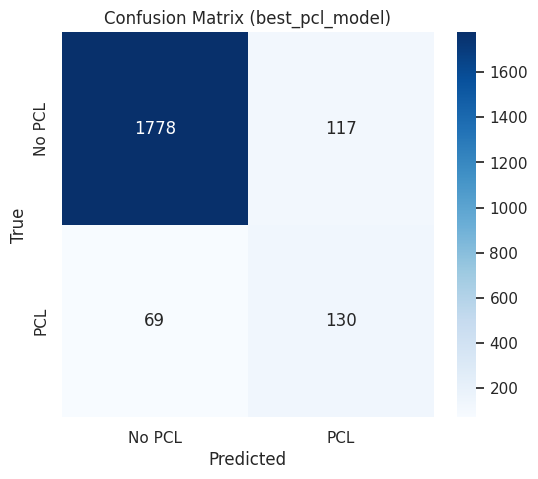


Classification Report (Dev):

              precision    recall  f1-score   support

      No PCL       0.96      0.94      0.95      1895
         PCL       0.53      0.65      0.58       199

    accuracy                           0.91      2094
   macro avg       0.74      0.80      0.77      2094
weighted avg       0.92      0.91      0.92      2094



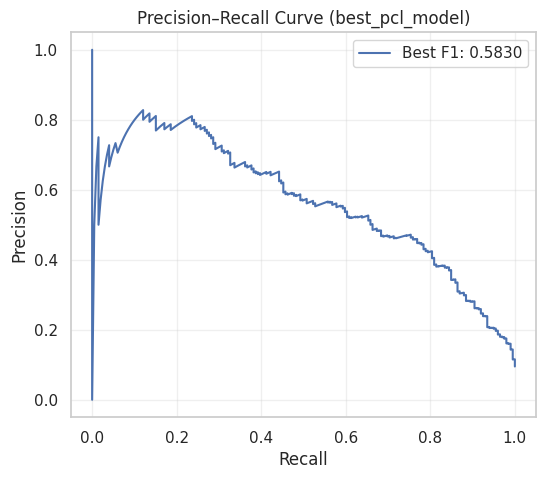

In [42]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, precision_recall_curve, f1_score)
from transformers import RobertaForSequenceClassification

sns.set_theme(style="whitegrid")

# =====================================================
# 1) Load 'best_pcl_model' for evaluation
# =====================================================
model_path = "/content/pcl_roberta_project_2/best_pcl_model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading model for evaluation from: {model_path}")
eval_model = RobertaForSequenceClassification.from_pretrained(model_path).to(device)
eval_model.eval()

# =====================================================
# 2) Get predictions on DEV set (test_dataset)
# =====================================================
all_logits = []
# We use the test_dataset created during the training stage
# which corresponds to the 20% validation split (test_split)
with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        outputs = eval_model(**inputs)
        all_logits.append(outputs.logits.cpu())

logits = torch.cat(all_logits, dim=0)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()

# Use the same best_threshold calculated during training or 0.5
y_true = test_split["final_label"].astype(int).values

# Recalculate optimal threshold for this specific model
precision, recall, thresholds = precision_recall_curve(y_true, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
opt_idx = np.argmax(f1_scores)
current_best_threshold = thresholds[min(opt_idx, len(thresholds)-1)]

y_pred = (probs >= current_best_threshold).astype(int)

dev_df = test_split.copy()
dev_df["prob_pcl"] = probs
dev_df["pred"] = y_pred
dev_df["correct"] = (dev_df["pred"] == dev_df["final_label"])

print(f"Optimal Threshold for this model: {current_best_threshold:.4f}")
print("Dev F1:", f1_score(y_true, y_pred))

# =====================================================
# 3) Confusion Matrix
# =====================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No PCL", "PCL"], yticklabels=["No PCL", "PCL"]
)
plt.title("Confusion Matrix (best_pcl_model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Dev):\n")
print(classification_report(y_true, y_pred, target_names=["No PCL", "PCL"]))

# =====================================================
# 4) Precision-Recall Curve
# =====================================================
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Best F1: {np.max(f1_scores):.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (best_pcl_model)")
plt.legend()
plt.show()


Error breakdown:
False Positives: 117
False Negatives: 69
True Positives:  130

----- FALSE POSITIVES (showing up to 5) -----

Keyword: disabled
True: 0  Pred: 1  Prob: 0.998
TEXT: disabled </s> The concern and attention to the disabled and weak has made Gov . Almakura special not only to Hammamatu , not only to Nasarawa State but to Nigeria as a whole .

Keyword: disabled
True: 0  Pred: 1  Prob: 0.994
TEXT: disabled </s> Supreme Court judge Sheikh Azmat Saeed while paying rich tribute to Pakistani women cricket team remarked " our government should tell if our women are disabled or crippled . Federal government neither grants them promotions nor allows them seniority as per the law " .

Keyword: vulnerable
True: 0  Pred: 1  Prob: 0.282
TEXT: vulnerable </s> Dissent and freedom of speech to make life safer and better for all of a nation 's citizens especially the most vulnerable and not only for a select few are at the core of a democracy .

Keyword: disabled
True: 0  Pred: 1  Prob: 0

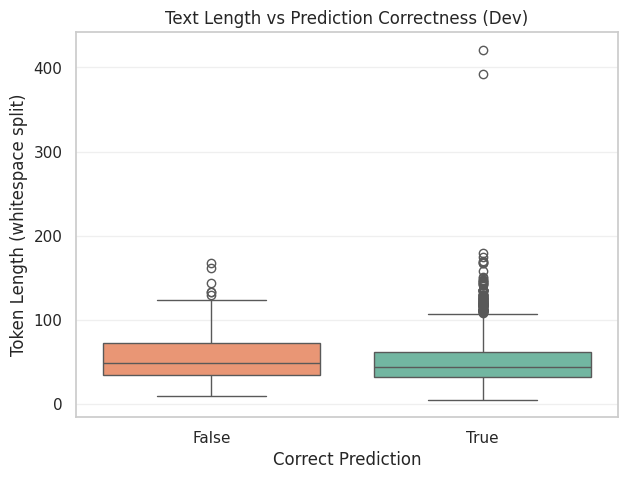

/tmp/ipykernel_1425/1682145694.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["pred"] != x["final_label"]).mean())



Keywords with highest error rates (top 10):
keyword
poor-families    0.170455
homeless         0.144033
in-need          0.117925
disabled         0.111675
hopeless         0.084577
vulnerable       0.070423
refugee          0.069264
women            0.059113
migrant          0.042857
immigrant        0.024038
dtype: float64


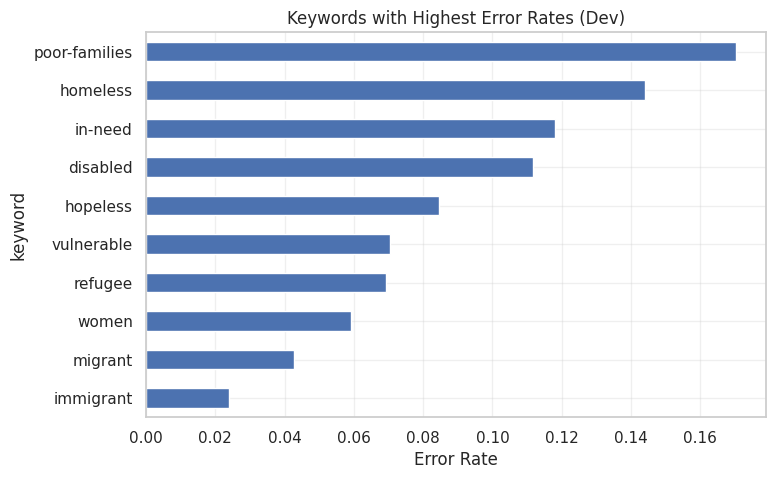


Hardest Examples (lowest confidence):
      keyword  final_label  pred  prob_pcl  confidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           text
poor-families            0     1  0.501592    0.001592                                                                                                                                                     

In [43]:
false_positives = dev_df[(dev_df["pred"] == 1) & (dev_df["final_label"] == 0)]
false_negatives = dev_df[(dev_df["pred"] == 0) & (dev_df["final_label"] == 1)]
true_positives  = dev_df[(dev_df["pred"] == 1) & (dev_df["final_label"] == 1)]

print("\nError breakdown:")
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("True Positives: ", len(true_positives))

# =====================================================
# 6) Show Example Errors (safe sampling)
# =====================================================
def show_examples(df, title, k=5):
    print(f"\n----- {title} (showing up to {k}) -----\n")
    if len(df) == 0:
        print("None.\n")
        return
    k = min(k, len(df))
    for _, row in df.sample(k, random_state=42).iterrows():
        print("Keyword:", row.get("keyword", ""))
        print("True:", int(row["final_label"]), " Pred:", int(row["pred"]), " Prob:", round(float(row["prob_pcl"]), 3))
        print("TEXT:", str(row.get("text", ""))[:400])
        print()

show_examples(false_positives, "FALSE POSITIVES")
show_examples(false_negatives, "FALSE NEGATIVES")

# =====================================================
# 7) Length vs Errors (fix palette/hue)
# =====================================================
dev_df["length"] = dev_df["text"].fillna("").astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=dev_df,
    x="correct",
    y="length",
    hue="correct",
    palette={False: "#fc8d62", True: "#66c2a5"},
    legend=False
)
plt.title("Text Length vs Prediction Correctness (Dev)")
plt.xlabel("Correct Prediction")
plt.ylabel("Token Length (whitespace split)")
plt.show()

# =====================================================
# 8) Keyword Error Analysis
# =====================================================
keyword_errors = (
    dev_df.groupby("keyword", dropna=False)
    .apply(lambda x: (x["pred"] != x["final_label"]).mean())
    .sort_values(ascending=False)
    .head(10)
)

print("\nKeywords with highest error rates (top 10):")
print(keyword_errors)

plt.figure(figsize=(8, 5))
keyword_errors.sort_values().plot(kind="barh")
plt.title("Keywords with Highest Error Rates (Dev)")
plt.xlabel("Error Rate")
plt.show()

# =====================================================
# 9) Hardest Examples (low confidence)
# =====================================================
dev_df["confidence"] = np.abs(dev_df["prob_pcl"] - 0.5)
hard_cases = dev_df.sort_values("confidence").head(10)

print("\nHardest Examples (lowest confidence):")
print(hard_cases[["keyword", "final_label", "pred", "prob_pcl", "confidence", "text"]].to_string(index=False))